# Numerical Integrator Comparison for Interacting Particle Systems

## Objective

This notebook analyses the numerical behaviour of three integration schemes—Euler, Runge–Kutta 4 (RK4), and Velocity Verlet—applied to a nonlinear interacting particle system.

We focus on:

- Energy conservation
- Momentum conservation
- Error scaling with timestep
- Stability and breakdown behaviour
- Sensitivity of qualitative dynamics

The objective is to distinguish between local numerical accuracy and long-term physical fidelity.

## Mathematical Model

The system evolves a set of charged particles under Newtonian dynamics.For each particle $i$:

### The equation of motion is:
$$ m_i \dfrac{\mathrm{d}\vec{v}_i}{\mathrm{d}t} = \sum_{j\neq i} \vec{F}_{ij} + \vec{F}_i^{ext}$$

### Pairwise Coulomb interaction (softened):
$$\vec{F}_{ij} = \dfrac{kq_iq_j}{(|\vec{r}_{ij}|^2 + \epsilon^2)^{3/2}} \vec{r}_{ij} $$

### External Lorentz force:
$$\vec{F}_i^{ext}  = q_i(\vec{E} + \vec{v}_i \times \vec{B})$$

where:
- $\vec{r_{ij}} = \vec{r_i} - \vec{r_j}$
- $\epsilon$ is a softening parameter preventing singularities

### Energy function:
$$E = \sum_{i} \dfrac{1}{2} m_i |\vec{v_i}|^2 + \sum_{i<j}\dfrac{kq_iq_j}{\sqrt{|\vec{r_{ij}}|^2 + \epsilon^2}}$$


## Numerical Methods

We compare three integrators:

- **Euler (1st order)**  
  $$
  \vec{x}_{n+1} = \vec{x}_n + \vec{v}_n dt
  $$

  $$
  \vec{v}_{n+1} = \vec{v}_n + \vec{a}_n dt
  $$

- **Runge–Kutta 4 (RK4, 4th order)**  

  $$
  k_1^x = \vec{v}_n, \quad
  k_1^v = \vec{a}(\vec{x}_n, \vec{v}_n)
  $$

  $$
  k_2^x = \vec{v}_n + \frac{dt}{2} k_1^v, \quad
  k_2^v = \vec{a}\left(\vec{x}_n + \frac{dt}{2} k_1^x,\ \vec{v}_n + \frac{dt}{2} k_1^v\right)
  $$

  $$
  k_3^x = \vec{v}_n + \frac{dt}{2} k_2^v, \quad
  k_3^v = \vec{a}\left(\vec{x}_n + \frac{dt}{2} k_2^x,\ \vec{v}_n + \frac{dt}{2} k_2^v\right)
  $$

  $$
  k_4^x = \vec{v}_n + dt\, k_3^v, \quad
  k_4^v = \vec{a}\left(\vec{x}_n + dt\, k_3^x,\ \vec{v}_n + dt\, k_3^v\right)
  $$

  $$
  \vec{x}_{n+1} = \vec{x}_n + \frac{dt}{6}\left(k_1^x + 2k_2^x + 2k_3^x + k_4^x\right)
  $$

  $$
  \vec{v}_{n+1} = \vec{v}_n + \frac{dt}{6}\left(k_1^v + 2k_2^v + 2k_3^v + k_4^v\right)
  $$

- **Velocity Verlet (2nd order, symplectic)**  
  $$
  \vec{x}_{n+1} = \vec{x}_n + \vec{v}_n dt + \frac{1}{2}\vec{a}_n dt^2
  $$
  $$
  \vec{v}_{n+1} = \vec{v}_n + \frac{1}{2}(\vec{a}_n + \vec{a}_{n+1})dt
  $$

Velocity Verlet is symplectic, meaning it preserves geometric structure and leads to bounded energy error over long times.

## Data Loading

Simulation outputs are stored as CSV files, each representing a single run with a given integrator and timestep.

We load and organise the data for analysis, while preparing for accurate plots.

In [1]:
# Imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Add project root to Python Path
project_root = Path("..").resolve()
sys.path.append(str(project_root / "src"))

from plots import load_data
from plots import finalize_plot

# Paths
ROOT = Path.cwd().parent
DATA = ROOT / "results" / "data"
FIGS = ROOT / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# Style
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

COLORS = {
    "euler": "tab:red",
    "rk4": "tab:blue",
    "verlet": "tab:green"
}

data = load_data(DATA)

## Hypotheses

- Euler will exhibit large and unbounded energy drift.
- RK4 will show the strongest error scaling with timestep.
- Velocity Verlet will preserve long-term energy behaviour.
- Large timesteps will lead to instability in all methods.

## Energy Drift Analysis

We examine how relative energy error evolves over time for different timesteps.

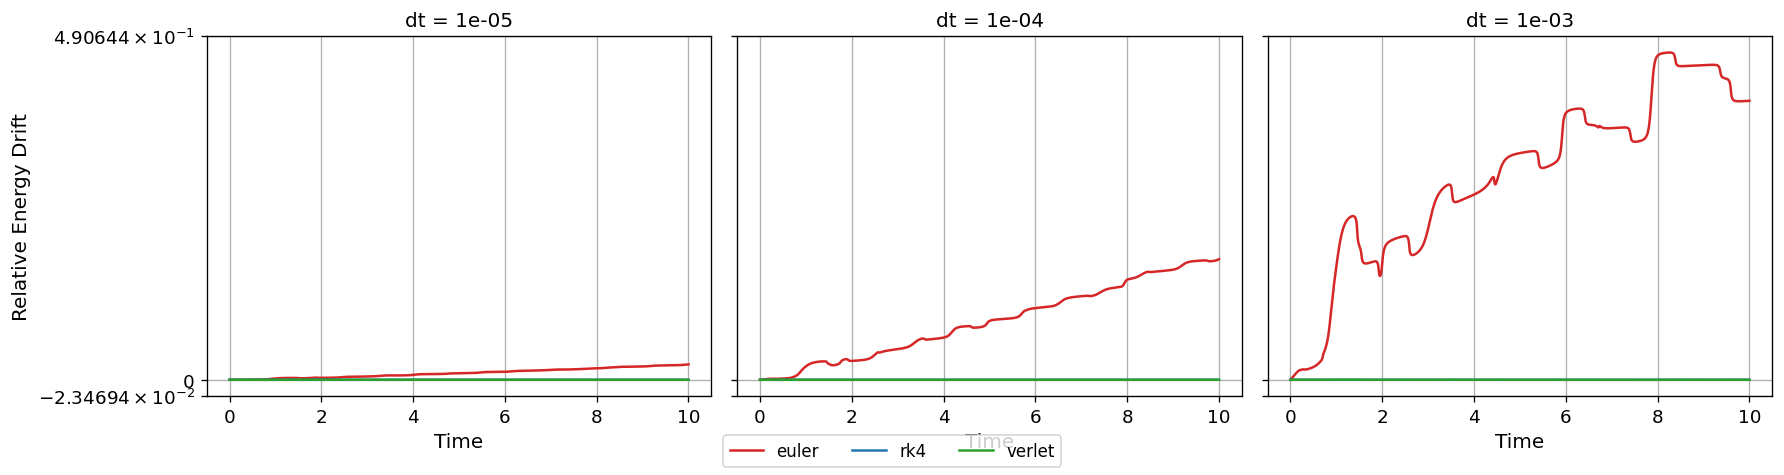

In [2]:
from metrics import energy_drift

selected_dts = [1e-5, 1e-4, 1e-3]
methods = list(data.keys())

fig, axes = plt.subplots(1, len(selected_dts), figsize=(5 * len(selected_dts), 4), sharey=True)

for ax, dt in zip(axes, selected_dts):
    for method in methods:
        for run_dt, df in data[method]:
            if np.isclose(run_dt, dt):
                drift = energy_drift(df)
                ax.plot(
                    df["t"],
                    drift,
                    label=method,
                    color=COLORS[method]
                )

    ax.set_title(f"dt = {dt:.0e}")
    ax.set_xlabel("Time")
    ax.set_yscale("symlog")
    ax.grid(True)

axes[0].set_ylabel("Relative Energy Drift")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.9])
finalize_plot("energy_by_dt.png", FIGS, show=True, save=False)

Euler exhibits significant energy drift, indicating systematic numerical instability. Although there are some decreases, there is a strong increasing trend.

RK4 and Velocity Verlet exhibit relatively small energy drift, but stil experience bounded oscillatory energy error. 

## Error Scaling with Timestep

We analyse how maximum energy error scales with timestep size.

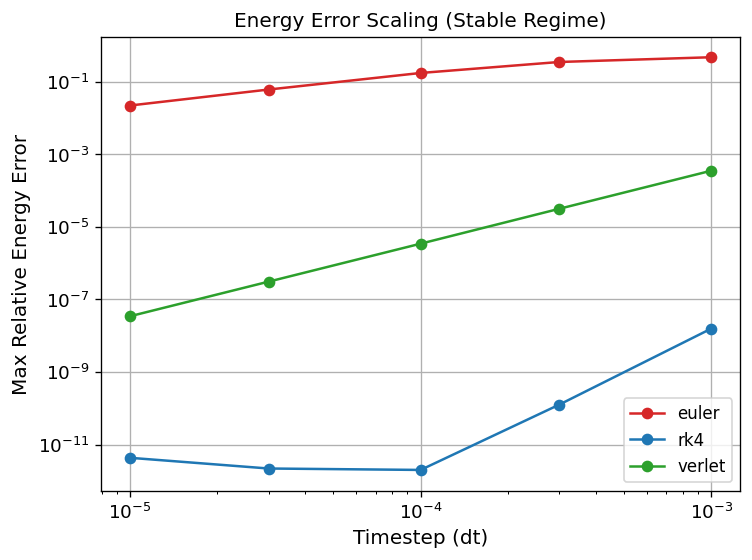

In [3]:
from metrics import max_energy_error

plt.figure()

for method, runs in data.items():
    dts = []
    errors = []

    for dt, df in runs:
        if dt >= 1e-2:  # exclude breakdown regime
            continue

        err = max_energy_error(df)

        dts.append(dt)
        errors.append(err)

    plt.plot(
        dts,
        errors,
        marker="o",
        label=method,
        color=COLORS[method]
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Timestep (dt)")
plt.ylabel("Max Relative Energy Error")
plt.title("Energy Error Scaling (Stable Regime)")
plt.legend()
plt.grid(True)

finalize_plot("energy_scaling.png", FIGS, show=True, save=False)

Euler shows the weakest convergence.

Velocity Verlet exhibits intermediate scaling.

The RK4 curve does not exhibit a clean power-law scaling across the full timestep range.

This is expected in the presence of non-smooth dynamics (collisions and discrete interaction events), which violate the smoothness assumptions required for classical Runge–Kutta convergence theory.

At small timesteps, the error approaches floating-point precision limits, leading to noise-dominated behaviour. At larger timesteps, interaction events are under-resolved, causing deviation from the asymptotic regime in which RK4 achieves its theoretical order of convergence.

As a result, RK4 does not display a single consistent scaling exponent in this system, despite its higher formal order.

## Empirical Convergence Rates

To quantify error scaling, we estimate the slope of the log–log relationship:

$$
\log(\text{error}) = p \log(dt) + C
$$

where $(p)$ is the observed order of convergence.

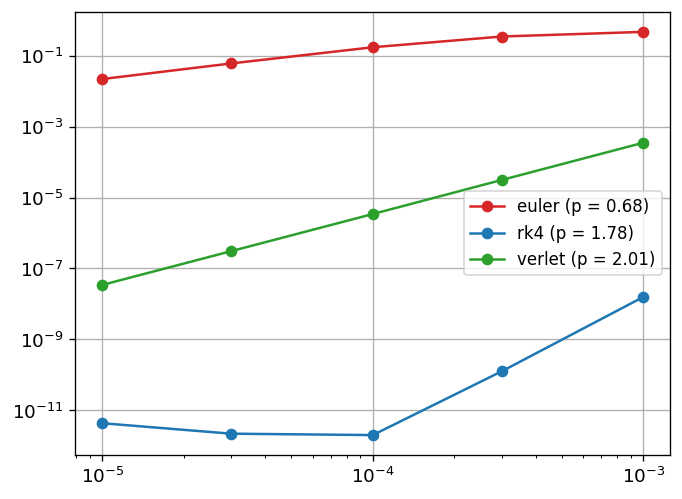

{'euler': np.float64(0.6827313762359135),
 'rk4': np.float64(1.780837064766892),
 'verlet': np.float64(2.005223288092529)}

In [4]:
orders = {}

plt.figure()

for method, runs in data.items():
    dts, errors = [], []

    for dt, df in runs:
        if dt >= 1e-2:
            continue
        dts.append(dt)
        errors.append(max_energy_error(df))

    dts = np.array(dts)
    errors = np.array(errors)

    log_dt = np.log(dts)
    log_err = np.log(errors)

    p, _ = np.polyfit(log_dt, log_err, 1)
    orders[method] = p

    plt.plot(
        dts,
        errors,
        marker="o",
        color=COLORS[method],
        label=f"{method} (p = {p:.2f})"
    )

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

orders

However, due to the non-smooth dynamics, we should also examine RK4 during a more regular time step regime $(dt \geq 10^{-4})$.

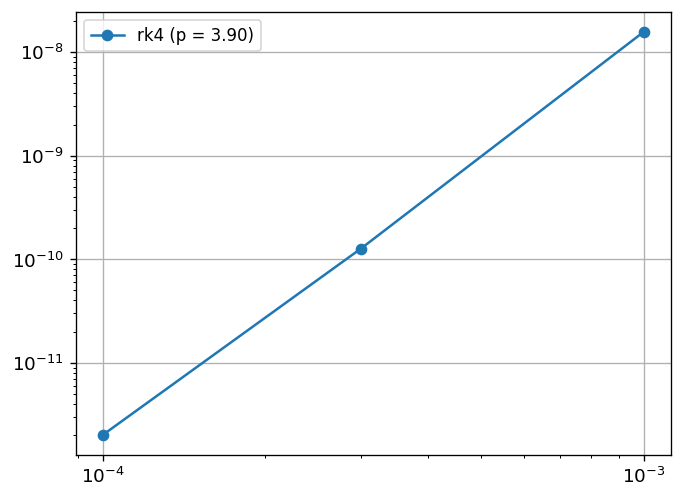

{'rk4': np.float64(3.895643002602093)}

In [5]:
orders = {}

plt.figure()

for method, runs in data.items():
    if method == "rk4":
        dts, errors = [], []

        for dt, df in runs:
            if dt >= 1e-2 or dt <1e-4:
                continue
            dts.append(dt)
            errors.append(max_energy_error(df))

        dts = np.array(dts)
        errors = np.array(errors)

        log_dt = np.log(dts)
        log_err = np.log(errors)

        p, _ = np.polyfit(log_dt, log_err, 1)
        orders[method] = p

        plt.plot(
        dts,
        errors,
        marker="o",
        color=COLORS[method],
        label=f"{method} (p = {p:.2f})"
        )

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

orders

Using the valid regime we can estimate the convergence orders:

- Euler: $\mathcal{O}(dt^{0.68})$
- Velocity Verlet: $\mathcal{O}(dt^{2.01})$
- RK4: $\mathcal{O}(dt^{3.90})$

In a suitable regime, RK4 demonstrates the highest convergence rate, consistent with its fourth-order formulation.

Velocity Verlet exhibits lower formal order but maintains stable behaviour due to its symplectic structure.

Euler shows poor convergence, reflecting first-order truncation error.

Observed deviations from theoretical values are expected due to:
- non-smooth collision dynamics
- discrete interaction events
- finite simulation horizon

## Momentum Conservation

Momentum is analytically conserved under internal forces.

Observed drift arises from numerical accumulation error.

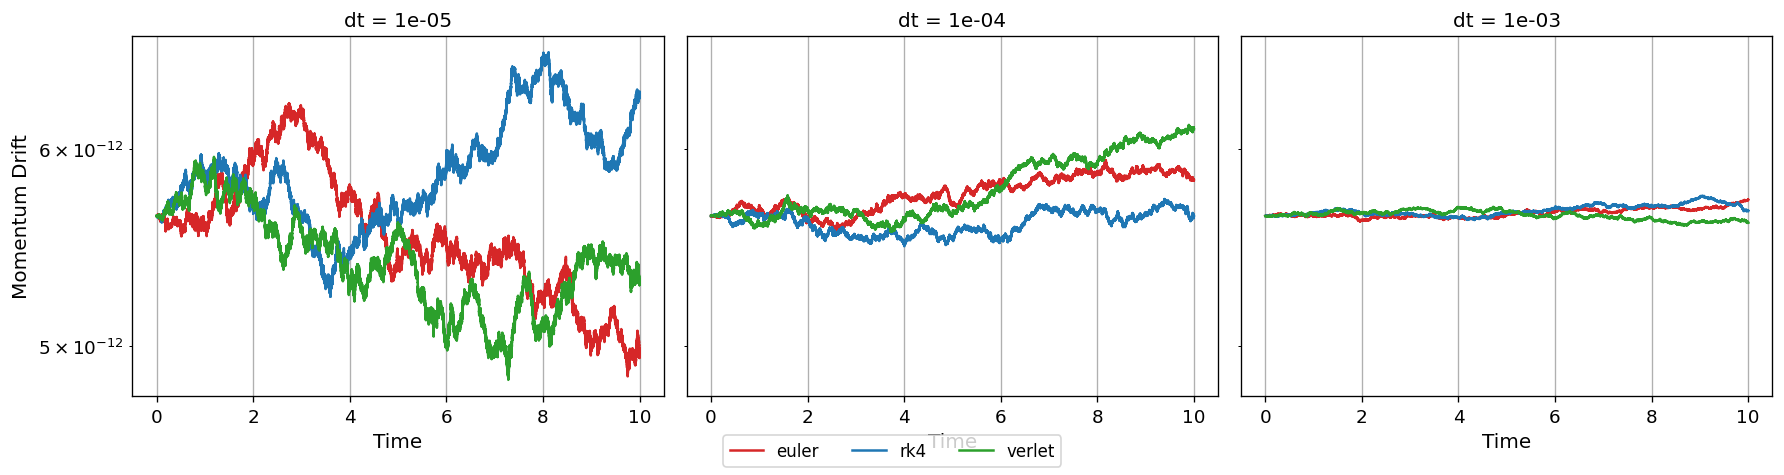

In [6]:
from metrics import momentum_drift

selected_dts = [1e-5, 1e-4, 1e-3]
methods = list(data.keys())

fig, axes = plt.subplots(1, len(selected_dts), figsize=(5 * len(selected_dts), 4), sharey=True)

for ax, dt in zip(axes, selected_dts):
    for method in methods:
        for run_dt, df in data[method]:
            if np.isclose(run_dt, dt):
                drift = momentum_drift(df)
                ax.plot(
                    df["t"],
                    drift,
                    label=method,
                    color=COLORS[method]
                )

    ax.set_title(f"dt = {dt:.0e}")
    ax.set_xlabel("Time")
    ax.set_yscale("log")
    ax.grid(True)

axes[0].set_ylabel("Momentum Drift")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.9])
finalize_plot("momentum_by_dt.png", FIGS, show=True, save=False)

Momentum drift increases with timestep count due to floating-point accumulation.

This behaviour is not method-specific but reflects numerical precision limits.

## Breakdown Regime

We examine behaviour at large timestep where numerical instability occurs.

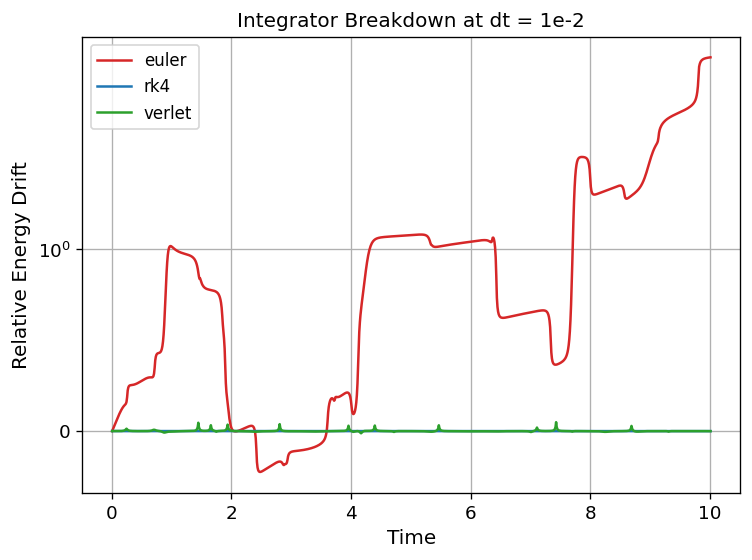

In [7]:
dt_target = 1e-2
methods = list(data.keys())

plt.figure()

for method in methods:
    for run_dt, df in data[method]:
        if np.isclose(run_dt, dt_target):
            drift = energy_drift(df)
            plt.plot(
                df["t"],
                drift,
                label=method,
                color=COLORS[method]
            )

plt.xlabel("Time")
plt.ylabel("Relative Energy Drift")
plt.title("Integrator Breakdown at dt = 1e-2")
plt.yscale("symlog")
plt.legend()
plt.grid(True)

finalize_plot("breakdown_dt_1e-2.png", FIGS, show=True, save=False)

Euler exhibits rapid changes in energy drift and eventually reaching high divergence.

Verlet and RK4 both exhibit less instability, but now the bounded energy drift oscillations are significantly more pronounced.

These correspond to numerical instability where timestep resolution is insufficient to resolve interaction dynamics.

## Sensitivity of Nonlinear Dynamics

With fusion enabled, small numerical differences lead to qualitatively different outcomes.

Integrator choice determines whether fusion thresholds are met, demonstrating sensitivity to perturbations in nonlinear systems.

## Limitations

- Collisions introduce non-smooth dynamics, affecting convergence.
- RK4 is implemented in a per-particle manner, which introduces coupling inconsistencies and may understate its true performance.
- Many non-smooth dynamics that disupt several integrator assumptions.
- The system is restricted to two dimensions.

## Conclusion

| Method | Stability Limit | Energy Growth | Convergence |
| ------ | --------------- | ------------- | ----------- |
| Euler  | Low             | High          |    0.68     |
| RK4    | Medium-high     | Bounded       |    3.90     |
| Verlet | High            | Bounded       |    2.01     |

Euler is unstable under nonlinear forcing, with error dominated by first-order truncation and rapid energy drift.

RK4 achieves the highest local accuracy and near fourth-order convergence in the regime where the dynamics remain sufficiently smooth. However, it does not preserve symplectic structure, so bounded local error does not imply bounded long-term energy behaviour.

Velocity Verlet is second-order accurate but symplectic, which leads to qualitatively stable long-time energy behaviour despite local truncation error.

Overall, the results separate local numerical accuracy from long-term dynamical fidelity: RK4 is optimal for short-time precision, while Velocity Verlet is preferable when conservation properties over long horizons are the primary requirement.